# Time-scale conversion across a leap-second boundary

GMAT emits epoch columns labelled with one of five time scales — A1, TAI, UTC, TT, TDB — and `gmat-run` promotes each one to `datetime64[ns]` *in its native scale*. When you want every column on a single time axis (say, plotting two missions against each other, or aligning a `ContactLocator` window with a ReportFile sample), `gmat_run.time` converts between scales using astropy's IERS-backed leap-second table.

This notebook demonstrates the conversion path end-to-end on a propagation that crosses the **2017-01-01** leap-second boundary, where TAI − UTC ticked from 36 s to 37 s. We:

1. Run a small mission whose `ReportFile` emits the same epoch in four scales (UTC / TAI / TT / TDB) plus an A1 numeric column.
2. Look at the per-column scale labels on `df.attrs["epoch_scales"]` before any conversion.
3. Convert one column with [`gmat_run.time.convert_column`][gmat_run.time.convert_column], then the whole frame with the parser-level `convert_to=` keyword.
4. Show A1 separately — it's GMAT-specific (astropy doesn't recognise it) and routes through TAI internally.
5. Plot TAI − UTC across the boundary so the 1-second leap-second jump is visible.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-run[astropy,examples]` for the time-scale module and matplotlib.


## Locate the script

The mission lives next to this notebook (`leap_second_demo.script`) — a minimal LEO whose epoch starts at 23:55:00 UTC on 2016-12-31, propagates 600 s with a fixed 30 s step, and writes a `ReportFile` carrying epoch columns in four scales side-by-side plus `Sat.A1ModJulian`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from gmat_run import Mission, locate_gmat
from gmat_run.parsers.reportfile import parse as parse_report
from gmat_run.time import convert, convert_column

install = locate_gmat()
script_path = Path("leap_second_demo.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       leap_second_demo.script
Exists:       True


## Run and inspect the native scales

`Mission.load(...).run()` parses the script, executes it headlessly, and exposes the resulting `ReportFile` lazily through `result.reports["RF"]`. The five epoch columns come back as `datetime64[ns]` — already typed timestamps, no further parsing required — and the *labelled* time scale for each column is recorded on `df.attrs["epoch_scales"]`. No conversion has happened yet: `Sat.UTCGregorian` is the UTC instant, `Sat.TAIGregorian` is the TAI instant of the same physical moment, etc.


In [2]:
mission = Mission.load(script_path)
result = mission.run()
df = result.reports["RF"]

print(f"Rows: {len(df)}")
print()
print("Native scale per column (df.attrs['epoch_scales']):")
for col, scale in df.attrs["epoch_scales"].items():
    print(f"  {col}: {scale}")
print()
print("Dtypes:")
print(df.dtypes)

Rows: 21

Native scale per column (df.attrs['epoch_scales']):
  Sat.UTCGregorian: UTC
  Sat.TAIGregorian: TAI
  Sat.TTGregorian: TT
  Sat.TDBGregorian: TDB
  Sat.A1ModJulian: A1

Dtypes:
Sat.UTCGregorian    datetime64[ns]
Sat.TAIGregorian    datetime64[ns]
Sat.TTGregorian     datetime64[ns]
Sat.TDBGregorian    datetime64[ns]
Sat.A1ModJulian     datetime64[ns]
Sat.X                      float64
Sat.Y                      float64
Sat.Z                      float64
dtype: object


## See the leap-second jump

GMAT integrates the propagation in atomic time, so TAI advances at a fixed 30 s per row. UTC, on the other hand, has a 1-second leap inserted at 2017-01-01 00:00:00. Before the boundary, TAI − UTC = 36 s; after, 37 s. The ReportFile carries both scales side-by-side, so we can read the offset directly off the DataFrame.

In [3]:
delta = (df["Sat.TAIGregorian"] - df["Sat.UTCGregorian"]).dt.total_seconds()
pd.DataFrame(
    {
        "Sat.UTCGregorian": df["Sat.UTCGregorian"],
        "TAI - UTC (s)": delta,
    }
)

,Sat.UTCGregorian,TAI - UTC (s)
0,2016-12-31 23:55:00,36.0
1,2016-12-31 23:55:30,36.0
2,2016-12-31 23:56:00,36.0
3,2016-12-31 23:56:30,36.0
4,2016-12-31 23:57:00,36.0
5,2016-12-31 23:57:30,36.0
6,2016-12-31 23:58:00,36.0
7,2016-12-31 23:58:30,36.0
8,2016-12-31 23:59:00,36.0
9,2016-12-31 23:59:30,36.0


## Per-column conversion

`gmat_run.time.convert_column(df, column, to_scale)` converts one promoted epoch column from its recorded source scale to a new target scale, updating `df.attrs["epoch_scales"][column]` in place. It is the right tool when you want to align *one* column without touching the others.

Below: convert `Sat.UTCGregorian` to TAI on a copy of the frame. The values shift by ~36–37 s (depending on which side of the leap second each row falls on), and the recorded scale label updates from `UTC` → `TAI`.

In [4]:
df_one = df.copy()
df_one.attrs["epoch_scales"] = dict(df.attrs["epoch_scales"])

before = df_one["Sat.UTCGregorian"].iloc[[0, -1]].tolist()
convert_column(df_one, "Sat.UTCGregorian", "TAI")
after = df_one["Sat.UTCGregorian"].iloc[[0, -1]].tolist()

scale = df_one.attrs["epoch_scales"]["Sat.UTCGregorian"]
print(f"epoch_scales['Sat.UTCGregorian'] is now: {scale!r}")
print(f"First row: {before[0]}  ->  {after[0]}")
print(f"Last row:  {before[1]}  ->  {after[1]}")

epoch_scales['Sat.UTCGregorian'] is now: 'TAI'
First row: 2016-12-31 23:55:00  ->  2016-12-31 23:55:36
Last row:  2017-01-01 00:04:59  ->  2017-01-01 00:05:36


## Whole-frame conversion via the parser

When you want *every* epoch column on a single scale (for joining DataFrames from different mission runs, or feeding a single time axis into downstream tooling), the parsers expose a `convert_to=` keyword that runs the whole conversion in one call. The same keyword is available on `parsers.reportfile.parse`, the three `EphemerisFile` parsers, and `parsers.aem_ephemeris.parse`.

We re-parse the report GMAT just wrote, asking for everything in UTC. After the call every entry in `df.attrs["epoch_scales"]` reads `UTC`, and the four other-scale columns line up with `Sat.UTCGregorian` row-by-row.

In [ ]:
report_path = result.report_paths["RF"]
df_utc = parse_report(report_path, convert_to="UTC")

print("All scales after convert_to='UTC':")
for col, scale in df_utc.attrs["epoch_scales"].items():
    print(f"  {col}: {scale}")

epoch_cols = [
    "Sat.UTCGregorian",
    "Sat.TAIGregorian",
    "Sat.TTGregorian",
    "Sat.TDBGregorian",
    "Sat.A1ModJulian",
]
df_utc[epoch_cols].head(3)

## A1: a GMAT-specific scale

Astropy's leap-second table doesn't know A1. Per the GMAT Mathematical Specification §2.1, A1 leads TAI by a fixed 0.0343817 s, so `gmat_run.time` routes A1 through TAI by applying that offset before/after the astropy step. From a caller's perspective A1 is just another scale name — `convert(series, "A1", "UTC")` works exactly like the other directions.

Below we take the GMAT-emitted A1 column, ask `convert` for UTC, and check it agrees with the GMAT-emitted `Sat.UTCGregorian` column to within a few hundred nanoseconds (GMAT's own A1↔TAI offset is rounded internally — see the [Time scales reference](../reference/time.md) for the exact value `gmat_run.time` uses).

In [6]:
a1_to_utc = convert(df["Sat.A1ModJulian"], "A1", "UTC")
max_diff = (a1_to_utc - df["Sat.UTCGregorian"]).abs().max()
print(f"max |convert(A1 -> UTC) - GMAT UTC| = {max_diff}")

pd.DataFrame(
    {
        "Sat.A1ModJulian (A1)": df["Sat.A1ModJulian"].iloc[:3],
        "convert(A1 -> UTC)": a1_to_utc.iloc[:3],
        "Sat.UTCGregorian (GMAT)": df["Sat.UTCGregorian"].iloc[:3],
    }
)

max |convert(A1 -> UTC) - GMAT UTC| = 0 days 00:00:00.000000513


,Sat.A1ModJulian (A1),convert(A1 -> UTC),Sat.UTCGregorian (GMAT)
0,2016-12-31 23:55:36.034381623,2016-12-31 23:54:59.999999923,2016-12-31 23:55:00
1,2016-12-31 23:56:06.034381405,2016-12-31 23:55:29.999999705,2016-12-31 23:55:30
2,2016-12-31 23:56:36.034381187,2016-12-31 23:55:59.999999487,2016-12-31 23:56:00


## Plot TAI − UTC across the boundary

The 1-second leap second sits right between rows 10 and 11 (UTC 2016-12-31 23:59:30 → 2017-01-01 00:00:00). Stepping the offset through the propagation makes the discontinuity obvious — and matches the IERS leap-second history for 2017-01-01.

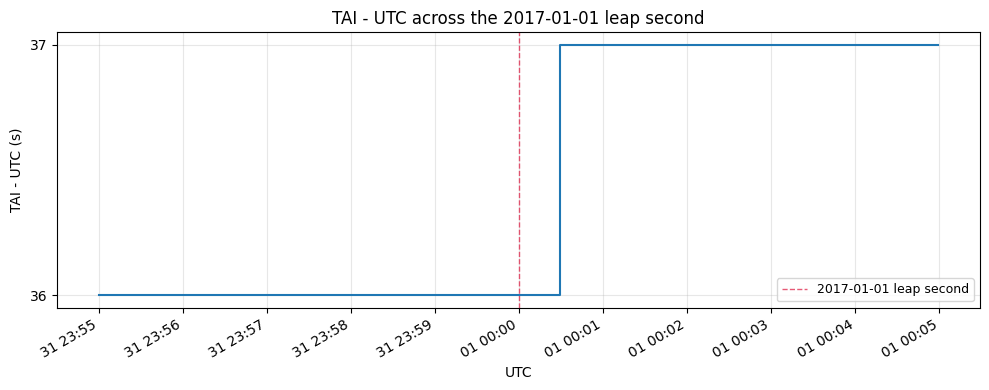

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(df["Sat.UTCGregorian"], delta, where="post", linewidth=1.5)
ax.axvline(
    pd.Timestamp("2017-01-01 00:00:00"),
    color="crimson",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="2017-01-01 leap second",
)
ax.set_xlabel("UTC")
ax.set_ylabel("TAI - UTC (s)")
ax.set_title("TAI - UTC across the 2017-01-01 leap second")
ax.set_yticks([36, 37])
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Where to next

- **Parser-level `convert_to`.** Every parser whose output carries `df.attrs["epoch_scales"]` accepts `convert_to=` — including the three `EphemerisFile` parsers (`parsers.ephemeris.parse` for CCSDS-OEM, `parsers.stk_ephemeris.parse`, and `parsers.aem_ephemeris.parse` for CCSDS-AEM). Use it whenever you want every epoch column on a single time axis without writing the per-column dance yourself.
- **Outside the GMAT five.** CCSDS files can declare `TIME_SYSTEM` values (`UT1`, `GPS`, `TCG`, …) that fall outside the five GMAT scales. `convert_to=` raises rather than silently mis-converting; reach for [`gmat_run.time.convert`][gmat_run.time.convert] once you have a mapping you trust.
- **A1 in your own code.** `convert(series, "A1", *)` and `convert(series, *, "A1")` work series-by-series — handy if you need to interoperate with another tool that emits A1 modified Julian dates.
